# Notebook 2: Log-Pearson Type 3 (LP3) Distribution — Bayesian Flood Frequency Analysis

## The LP3 Distribution and Australian Practice

The **Log-Pearson Type 3 (LP3)** distribution is the standard for flood frequency analysis in **Australian Rainfall and Runoff (ARR 2019)**. It is also mandated for US federal agencies under Bulletin 17C. Its dominance in practice reflects both strong empirical performance on Australian records and decades of institutional familiarity.

### How LP3 Works

LP3 is a two-step model. First, take the natural logarithm of flows: $Y = \ln(Q)$. Then fit a **Pearson Type 3 (P3)** distribution to $Y$:

$$Y \sim \text{Pearson Type 3}(\mu_Y,\, \sigma_Y,\, \gamma)$$

The three parameters are:

| Parameter | Symbol | Role in log-space |
|---|---|---|
| Location | $\mu_Y$ | Mean of log-flows — controls the typical flood magnitude |
| Scale | $\sigma_Y > 0$ | Standard deviation of log-flows — controls spread |
| Skewness | $\gamma$ | Controls asymmetry — positive means upper tail is heavier |

Return levels are computed in log-space and **back-transformed** by exponentiation: $Q_T = e^{Y_T}$. All flow values in the plots are in m³/s.

### Why Skewness Matters

The skewness coefficient $\gamma$ is the most influential and most uncertain LP3 parameter. It controls how quickly the distribution rises in the upper tail. A single extreme event (like 2021) can dramatically shift the sample skewness estimate, making it unstable for short records. ARR 2019 recommends weighting the at-site skewness with **regional skewness information** to reduce this instability — the Bayesian prior on $\gamma$ serves a similar regularising role here.

### Comparison with GEV

Both GEV and LP3 are three-parameter distributions. Their key difference is theoretical: GEV has a direct EVT justification (block maxima theorem), while LP3 is empirically motivated via the log-transform. In practice on Australian data, they produce similar estimates in the central range (10%–1% AEP) but can diverge in the upper tail — a difference explored in Notebook 4.

In [1]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from flood_ffa.data.bom import load_ams, get_flow_series
from flood_ffa.lp3.fit import fit_lp3
from flood_ffa.lp3.plots import plot_trace, plot_corner, plot_return_levels

## 1. Annual Maximum Series

We use the same 55-year AMS dataset (1970–2024) as Notebook 1. The LP3 model operates internally on log-transformed flows — `fit_lp3()` applies `np.log()` before passing data to PyMC. All results are back-transformed to m³/s for reporting and plotting.

In [2]:
df = load_ams("../data/AMS.csv")
flows = get_flow_series(df)

## 2. Bayesian LP3 Model

### Prior Distributions

The LP3 model is fitted in log-space, so priors are specified on log-transformed quantities:

| Parameter | Prior | Rationale |
|---|---|---|
| $\mu_Y$ | $\text{Normal}(\overline{\ln Q},\, s_{\ln Q})$ | Centred on the sample log-mean — weakly informative |
| $\sigma_Y$ | $\text{HalfNormal}(s_{\ln Q})$ | Must be positive; centred on log-space spread |
| $\gamma$ | $\text{Normal}(0,\, 0.5)$ | Centred at zero (symmetric); ARR guidance suggests near-zero skew for many Australian catchments |

The skewness prior is the critical choice. `Normal(0, 0.5)` acts as a weak regulariser — it pulls the posterior toward zero skewness when data are limited, while still allowing the 2021 outlier to drive a positive estimate. This mirrors the ARR practice of weighting at-site skewness with a regional value.

### PyTensor Implementation

`scipy.stats.pearson3` cannot be used directly inside a PyMC model — it is not part of PyMC's automatic differentiation (PyTensor) computation graph, so NUTS cannot compute the gradients it needs. The LP3 log-probability function is therefore implemented from scratch using PyTensor operations, including `pt.special.gammaln` for the log-gamma function. This is transparent to the user: `fit_lp3()` handles it internally.

In [3]:
idata_lp3 = fit_lp3(flows, draws=2000, tune=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, skew]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 44 seconds.
There were 56 divergences after tuning. Increase `target_accept` or reparameterize.


### A Note on Divergences

The LP3 model typically produces more divergences than the GEV model. This reflects the geometry of the Pearson Type 3 log-probability surface: the boundary condition on the support (the distribution requires $u = \beta z + \alpha > 0$ for valid density) creates a curved boundary in parameter space that NUTS finds challenging.

**Assessing validity**: Check r̂ and ESS in the parameter summary table. If r̂ ≈ 1.00 and ESS > 400 for all three parameters, the posterior estimates are reliable. A higher divergence count with good convergence diagnostics indicates the sampler struggled geometrically but ultimately found the correct posterior.

If divergences are very high (> several hundred), consider running `fit_lp3(flows, target_accept=0.95)` to force a more conservative step size.

## 3. Posterior Diagnostics: Trace Plots

Examine the trace plots for all three LP3 parameters in log-space ($\mu_Y$, $\sigma_Y$, $\gamma$). Check for:

- **Good chain mixing**: All 4 chains should interleave throughout — no visible separation.
- **Stationarity**: No trends or drifts in the sampled values.
- **Unimodal densities**: The marginal density plots (right panel) should show a single peak per parameter.

The skewness parameter $\gamma$ typically has the broadest posterior — this reflects the genuine difficulty of estimating tail asymmetry from a 55-year record. A wide $\gamma$ posterior propagates directly into wide HDI bands at rare return periods.

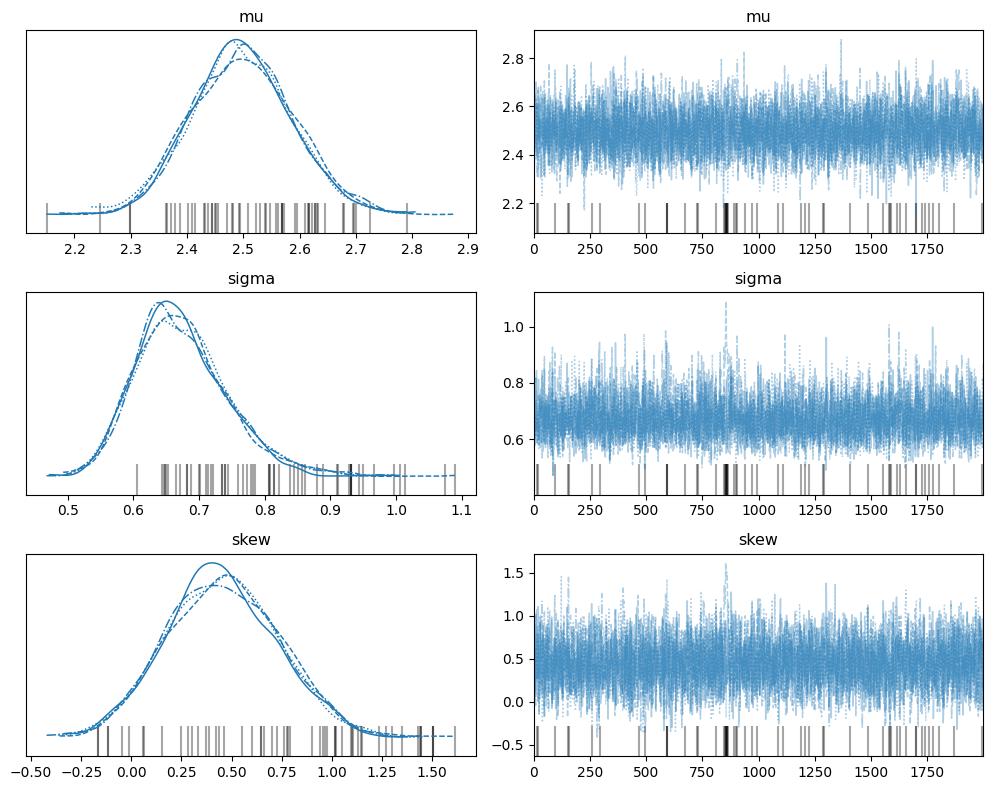

In [4]:
plot_trace(idata_lp3);
plt.show()

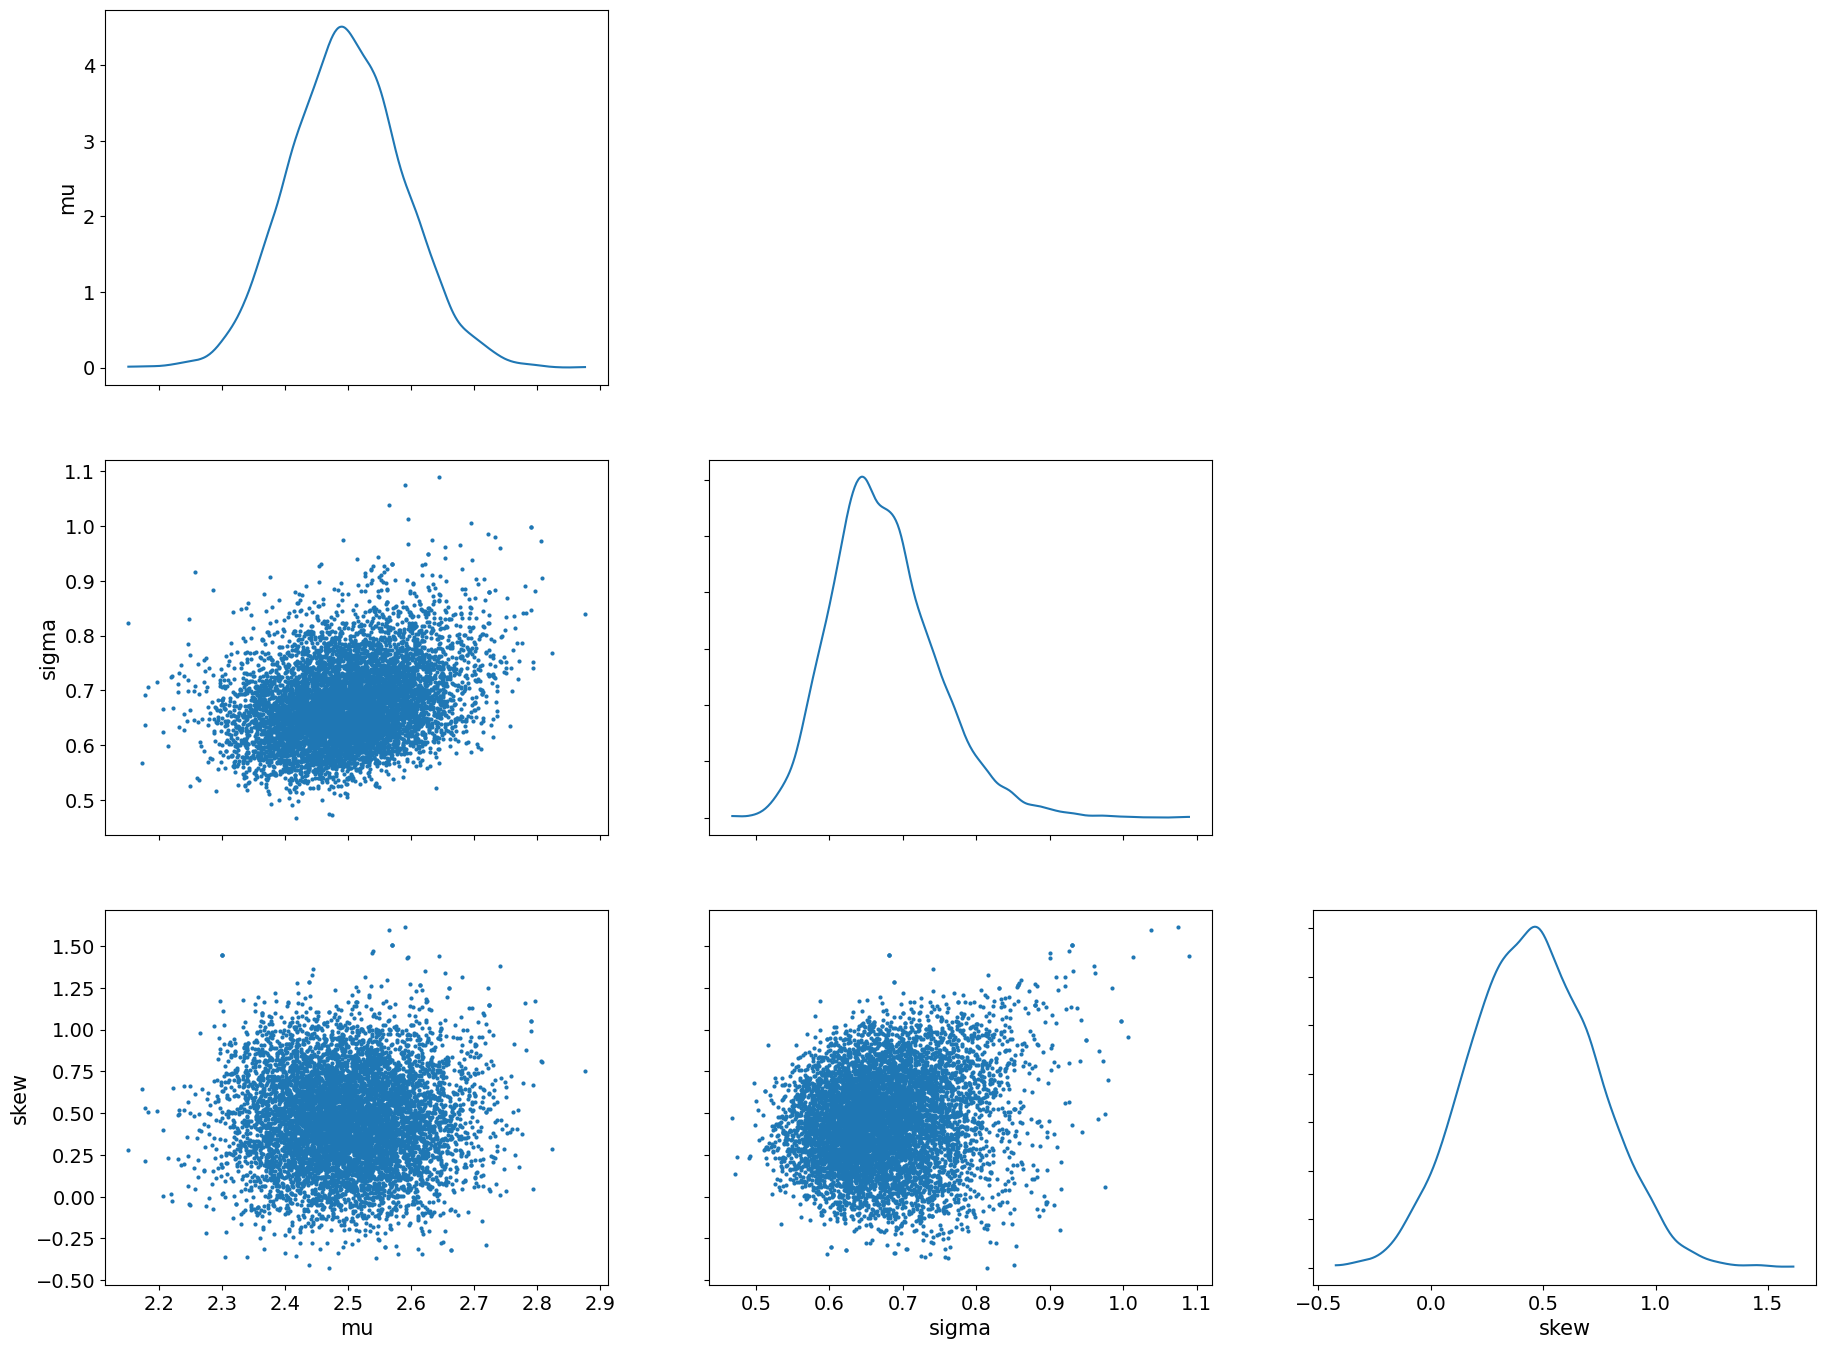

In [5]:
from flood_ffa.lp3.plots import plot_corner
plot_corner(idata_lp3);
plt.show()

## 3b. Posterior Correlations: Corner (Pair) Plot

The corner plot shows the joint posterior distributions for all LP3 parameter pairs. Key relationships to examine:

- **$\mu_Y$ vs $\sigma_Y$**: A mild positive correlation is expected — larger location and scale both shift the distribution rightward.
- **$\sigma_Y$ vs $\gamma$**: Often the strongest correlation in the LP3 posterior. Both parameters control tail behaviour in log-space, and they trade off against each other.
- **Width of the $\gamma$ marginal**: The skewness posterior is typically the broadest — reflecting the fundamental difficulty of estimating tail asymmetry from a 55-year record with a single dominant outlier.

## 4. Flood Frequency Curve

Return levels are computed by evaluating the LP3 quantile function in log-space for each posterior sample:

$$\ln Q_T = \mu_Y + \sigma_Y \cdot K_T(\gamma)$$

where $K_T(\gamma)$ is the **frequency factor** — the quantile of the standardised Pearson Type 3 distribution with skewness $\gamma$ at the target non-exceedance probability. The log-space quantile is then exponentiated: $Q_T = e^{\ln Q_T}$.

The uncertainty band reflects the combined posterior uncertainty in all three parameters ($\mu_Y$, $\sigma_Y$, $\gamma$). Because the skewness is poorly constrained by 55 years of data, the LP3 HDI band is typically comparable in width to the GEV band.

Note: all values on the Y axis are already back-transformed to m³/s.

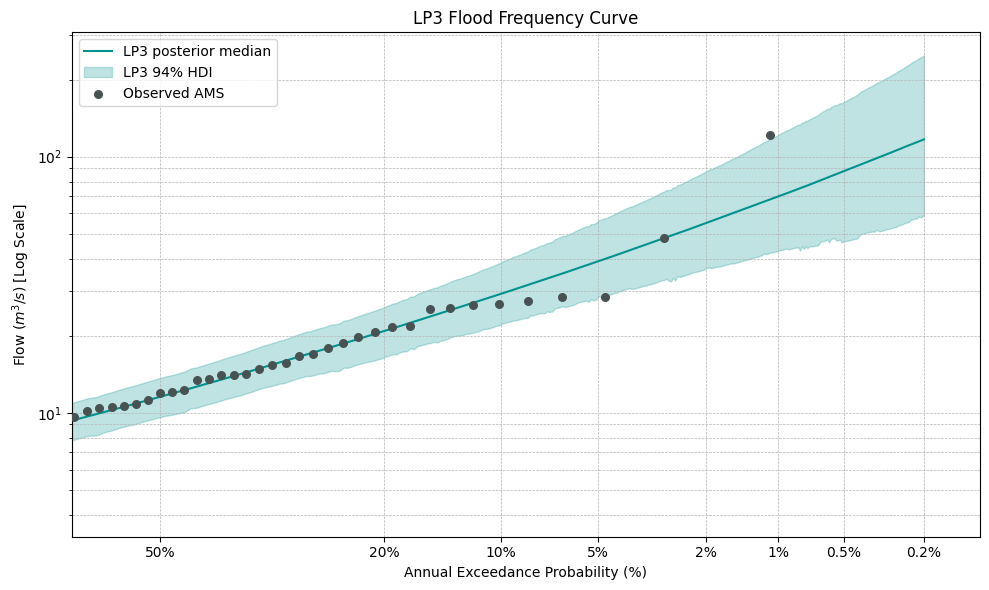

In [6]:
plot_return_levels(idata_lp3, flows);
plt.show()

In [7]:
idata_lp3


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

## 5. Posterior Parameter Summary

LP3 parameters are estimated in log-space. To connect them to physical quantities:

- **$\mu_Y \approx 2.50$**: The log-space location. Back-transformed: $e^{2.50} \approx 12.2$ m³/s — this is approximately the median annual maximum flow, consistent with visual inspection of the record.
- **$\sigma_Y \approx 0.675$**: The log-space scale. Reflects moderate variability in the record.
- **$\gamma \approx 0.45$, 94% HDI (−0.05 to 1.00)**: The skewness is **positive**, consistent with the 2021 outlier pulling the distribution rightward. However, the HDI spans zero — the data does not conclusively determine the sign. This is a common finding for records of this length and highlights the instability of the skewness estimator.

Check r̂ for all parameters (target < 1.01) and ESS (target > 400) to confirm valid convergence. The `mcse_mean` values should be well below 10% of the posterior standard deviation.

In [8]:
az.summary(idata_lp3, hdi_prob=0.94)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,2.497,0.090,2.332,2.666,0.001,0.001,4836.0,3959.0,1.0
skew,0.458,0.281,-0.051,0.994,0.004,0.005,4233.0,3171.0,1.0
sigma,0.674,0.072,0.549,0.811,0.001,0.002,4167.0,2574.0,1.0
